# Feature Importance Consistency Across Models

This notebook compares which features different machine learning models identify as important for type 2 diabetes prediction, using SHAP values as the explainability method.

Models are compared within each preprocessing strategy separately:
- **Section A:** SMOTE — comparing all four models trained on SMOTE-resampled data
- **Section B:** Undersampling — comparing all four models trained on undersampled data

**Methods used:**
- Top-10 overlap — how many of the top 10 features are shared between two models
- Spearman rank correlation — how similar the full feature rankings are between two models
- Jaccard similarity — set-based overlap of the top-10 feature lists

**Input:** `results/features/*_feature_importance.csv` (SHAP only)
**Output:** `results/figures/rq2_*.png`

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import spearmanr
from itertools import combinations

plt.rcParams.update({
    'font.family':       'sans-serif',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'figure.dpi':        120,
})

os.makedirs("../results/figures/model_feature_consistency", exist_ok=True)

MODEL_COLORS = {
    "Logistic Regression": "#3266ad",
    "Random Forest":        "#2a8a5e",
    "XGBoost":              "#a04e0a",
    "Decision Tree":        "#7a3090",
}
MODELS = list(MODEL_COLORS.keys())
TOP_N  = 10


## Loading SHAP Feature Importance Data

All feature importance CSV files are loaded and filtered to retain only SHAP results. The data is split by preprocessing strategy so that SMOTE models are only compared with other SMOTE models, and undersampling models only with other undersampling models.

In [2]:
files = glob.glob("../results/features/*_feature_importance.csv")

if not files:
    raise FileNotFoundError("No feature importance files found. Run all model notebooks first.")

raw_df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

# Keep only SHAP results
shap_df = raw_df[raw_df["Method"] == "SHAP"].copy()

# Split by strategy
smote_df = shap_df[shap_df["Strategy"] == "SMOTE"].copy()
under_df = shap_df[shap_df["Strategy"] == "Undersampling"].copy()

print("Models in SMOTE:",        smote_df["Model"].unique())
print("Models in Undersampling:", under_df["Model"].unique())
print("Total features per model:", shap_df.groupby(["Model", "Strategy"])["Feature"].count().values[0])


Models in SMOTE: ['Decision Tree' 'XGBoost' 'Logistic Regression' 'Random Forest']
Models in Undersampling: ['Logistic Regression' 'XGBoost' 'Decision Tree' 'Random Forest']
Total features per model: 36


## Helper Functions

Three functions compute the consistency metrics between two models:
- `top_n_overlap` — count of shared features in the top N
- `spearman_correlation` — Spearman rank correlation over the full feature ranking
- `jaccard_similarity` — size of intersection divided by size of union for the top N feature sets

In [3]:
def get_top_n(df, model, strategy, n=TOP_N):
    """Return the top-N feature names for a given model and strategy."""
    subset = df[(df["Model"] == model) & (df["Strategy"] == strategy)]
    return set(subset.nsmallest(n, "Rank")["Feature"].tolist())


def get_full_ranking(df, model, strategy):
    """Return a Series of importance scores indexed by feature, sorted by rank."""
    subset = df[(df["Model"] == model) & (df["Strategy"] == strategy)]
    return subset.set_index("Feature")["Rank"].sort_values()


def top_n_overlap(df, model_a, model_b, strategy, n=TOP_N):
    """Number of shared features in the top N between two models."""
    top_a = get_top_n(df, model_a, strategy, n)
    top_b = get_top_n(df, model_b, strategy, n)
    return len(top_a & top_b)


def spearman_correlation(df, model_a, model_b, strategy):
    """Spearman rank correlation of full feature rankings between two models."""
    rank_a = get_full_ranking(df, model_a, strategy)
    rank_b = get_full_ranking(df, model_b, strategy)
    # Align on common features
    common = rank_a.index.intersection(rank_b.index)
    corr, _ = spearmanr(rank_a[common], rank_b[common])
    return round(corr, 4)


def jaccard_similarity(df, model_a, model_b, strategy, n=TOP_N):
    """Jaccard similarity of top-N feature sets between two models."""
    top_a = get_top_n(df, model_a, strategy, n)
    top_b = get_top_n(df, model_b, strategy, n)
    if not top_a | top_b:
        return 0.0
    return round(len(top_a & top_b) / len(top_a | top_b), 4)


def build_pairwise_matrix(df, strategy, metric_fn):
    """Build a symmetric matrix of pairwise scores for all model combinations."""
    available = df[df["Strategy"] == strategy]["Model"].unique().tolist()
    mat = pd.DataFrame(np.nan, index=available, columns=available)
    for m in available:
        mat.loc[m, m] = 1.0 if metric_fn.__name__ in ("spearman_correlation", "jaccard_similarity") else TOP_N
    for a, b in combinations(available, 2):
        val = metric_fn(df, a, b, strategy)
        mat.loc[a, b] = val
        mat.loc[b, a] = val
    return mat


---
# Section A — SMOTE

All four models trained with SMOTE oversampling are compared on their SHAP feature rankings.

## A1. Top-10 Feature Rankings per Model (SMOTE)

The top 10 features by mean absolute SHAP value for each model. Comparing these charts side-by-side gives an immediate visual sense of how much agreement exists between models.

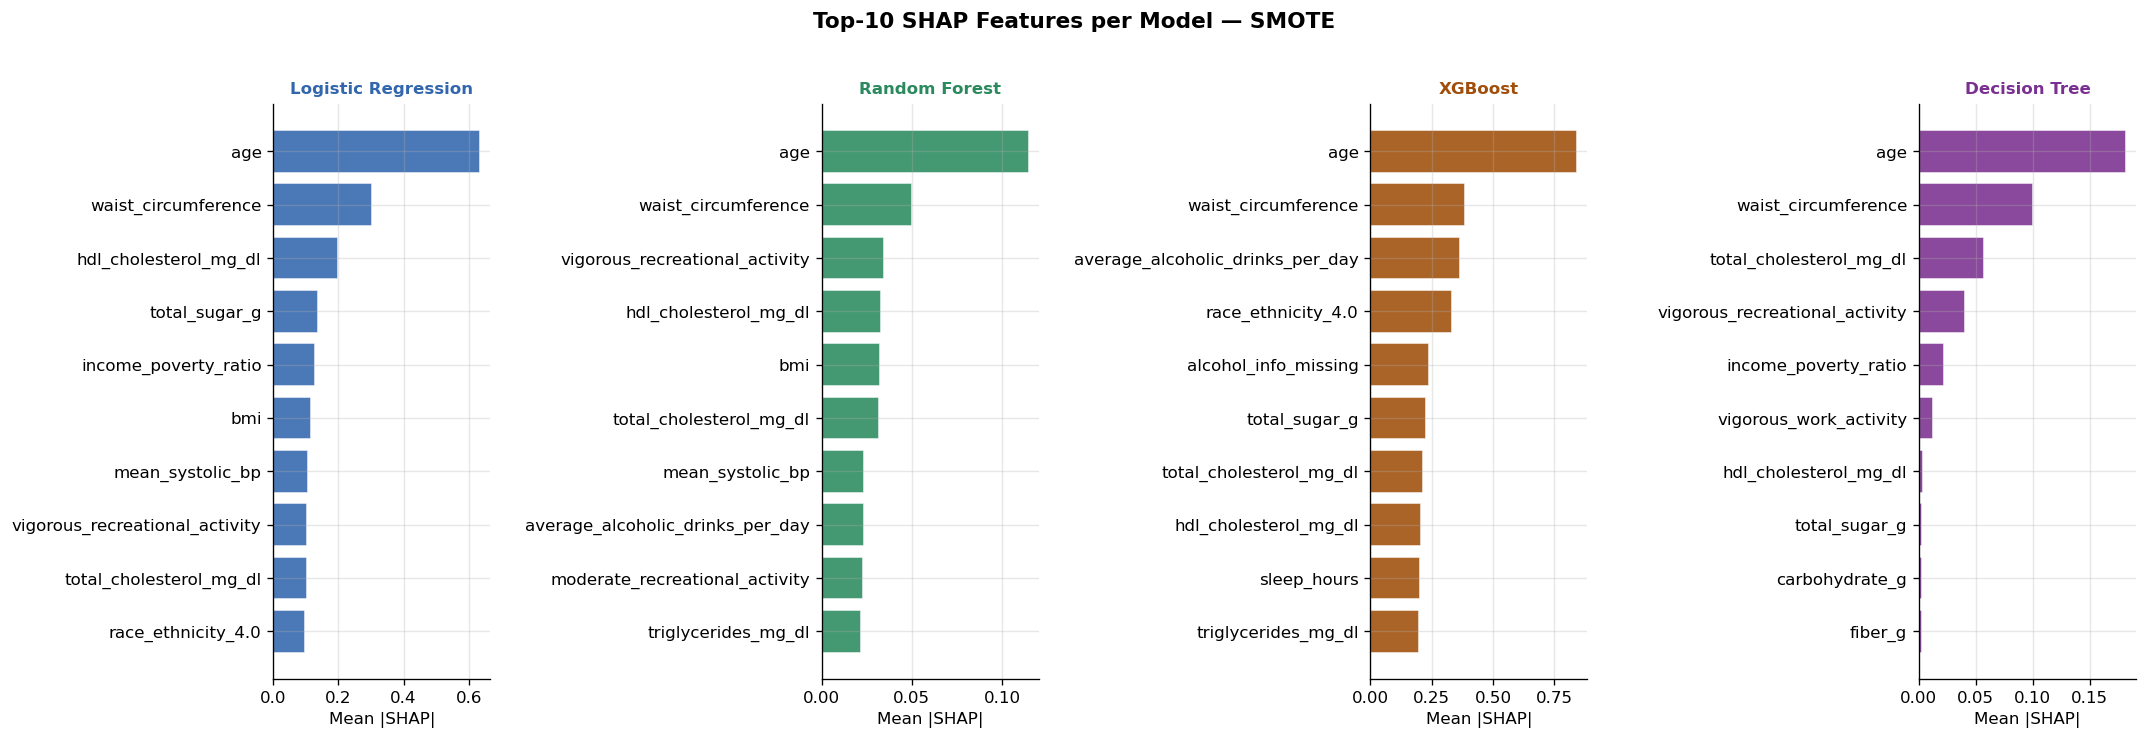

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(18, 6), sharey=False)

for ax, model in zip(axes, MODELS):
    subset = smote_df[smote_df["Model"] == model].nsmallest(TOP_N, "Rank")
    if subset.empty:
        ax.set_title(f"{model}\n(no data)", fontsize=10)
        continue
    subset = subset.sort_values("Importance", ascending=True)
    ax.barh(subset["Feature"], subset["Importance"],
            color=MODEL_COLORS[model], edgecolor="white", alpha=0.88)
    ax.set_title(model, fontsize=10, fontweight="bold", color=MODEL_COLORS[model])
    ax.set_xlabel("Mean |SHAP|")

fig.suptitle(f"Top-{TOP_N} SHAP Features per Model — SMOTE",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../results/figures/model_feature_consistency/model_a_top10_bars.png", bbox_inches="tight")
plt.show()


## A2. Top-10 Overlap Heatmap (SMOTE)

Each cell shows how many of the top 10 features are shared between two models. A value of 10 means perfect agreement; 0 means no shared features in the top 10.

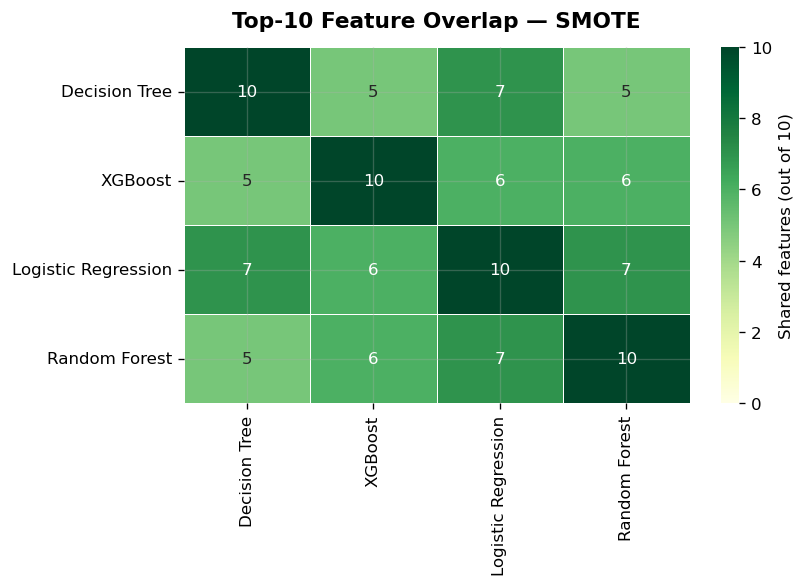

Mean pairwise overlap (excl. diagonal): 6.0


In [5]:
overlap_smote = build_pairwise_matrix(shap_df, "SMOTE", top_n_overlap)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    overlap_smote.astype(float),
    annot=True, fmt=".0f", cmap="YlGn",
    vmin=0, vmax=TOP_N,
    linewidths=0.5, linecolor="white",
    ax=ax, cbar_kws={"label": f"Shared features (out of {TOP_N})"}
)
ax.set_title(f"Top-{TOP_N} Feature Overlap — SMOTE",
             fontsize=13, fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig("../results/figures/model_feature_consistency/model_a_overlap_heatmap.png", bbox_inches="tight")
plt.show()

print("Mean pairwise overlap (excl. diagonal):",
      round(overlap_smote.values[np.triu_indices_from(overlap_smote.values, k=1)].mean(), 2))


## A3. Spearman Rank Correlation Heatmap (SMOTE)

Spearman rank correlation is computed over the full feature ranking (all features, not just top 10). A value of 1.0 means the two models rank features identically; 0 means no correlation; -1 means inverse ranking. This is a stricter measure of consistency than top-10 overlap.

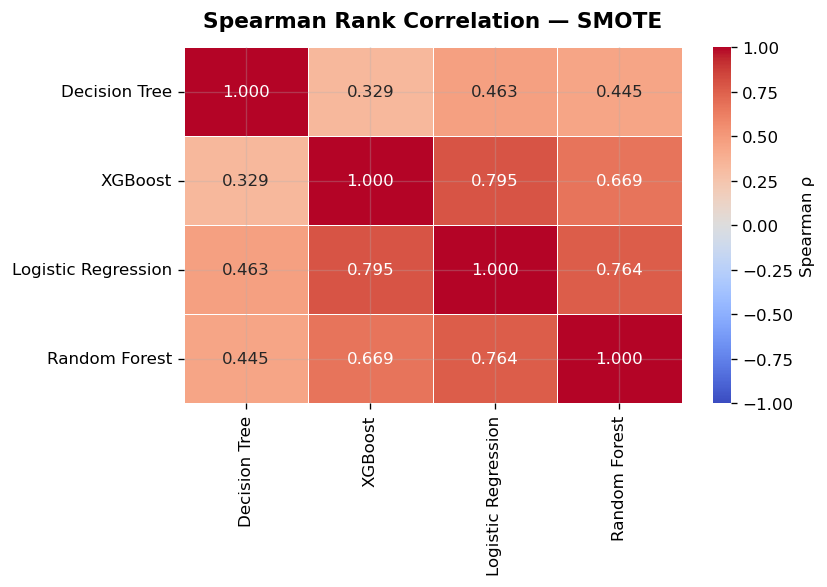

Mean Spearman ρ (excl. diagonal): 0.577
Min: 0.329  Max: 0.795


In [6]:
spearman_smote = build_pairwise_matrix(shap_df, "SMOTE", spearman_correlation)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    spearman_smote.astype(float),
    annot=True, fmt=".3f", cmap="coolwarm",
    vmin=-1, vmax=1, center=0,
    linewidths=0.5, linecolor="white",
    ax=ax, cbar_kws={"label": "Spearman ρ"}
)
ax.set_title("Spearman Rank Correlation — SMOTE",
             fontsize=13, fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig("../results/figures/model_feature_consistency/model_a_spearman_heatmap.png", bbox_inches="tight")
plt.show()

vals = spearman_smote.values[np.triu_indices_from(spearman_smote.values, k=1)]
print(f"Mean Spearman ρ (excl. diagonal): {vals.mean():.3f}")
print(f"Min: {vals.min():.3f}  Max: {vals.max():.3f}")


## A4. Jaccard Similarity (SMOTE)

Jaccard similarity is the size of the intersection divided by the size of the union of two top-10 feature sets. A value of 1.0 means the sets are identical; 0 means they share no features.

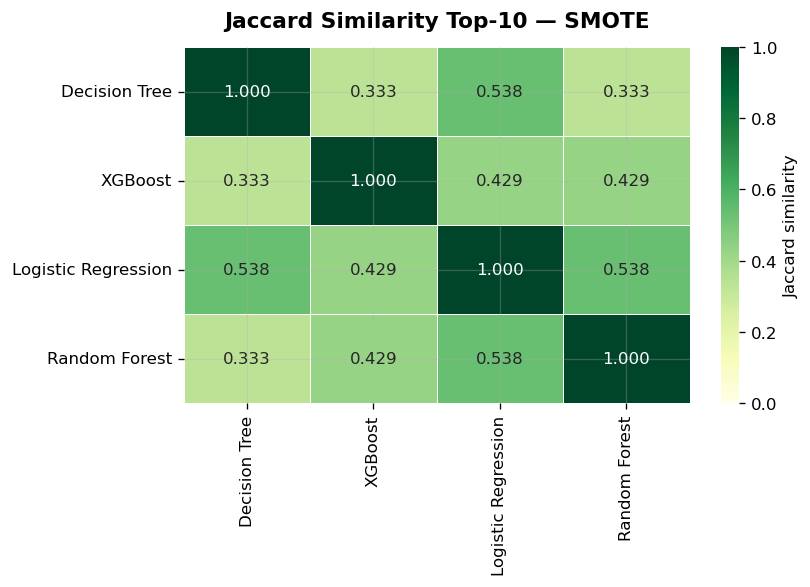

In [7]:
jaccard_smote = build_pairwise_matrix(shap_df, "SMOTE", jaccard_similarity)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    jaccard_smote.astype(float),
    annot=True, fmt=".3f", cmap="YlGn",
    vmin=0, vmax=1,
    linewidths=0.5, linecolor="white",
    ax=ax, cbar_kws={"label": "Jaccard similarity"}
)
ax.set_title(f"Jaccard Similarity Top-{TOP_N} — SMOTE",
             fontsize=13, fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig("../results/figures/model_feature_consistency/model_a_jaccard_heatmap.png", bbox_inches="tight")
plt.show()


## A5. Consensus Feature Ranking (SMOTE)

The consensus ranking aggregates feature importance across all four models by averaging their SHAP ranks. A lower average rank means a feature is consistently identified as important across models. Features with low variance in rank across models are the most consistently identified.

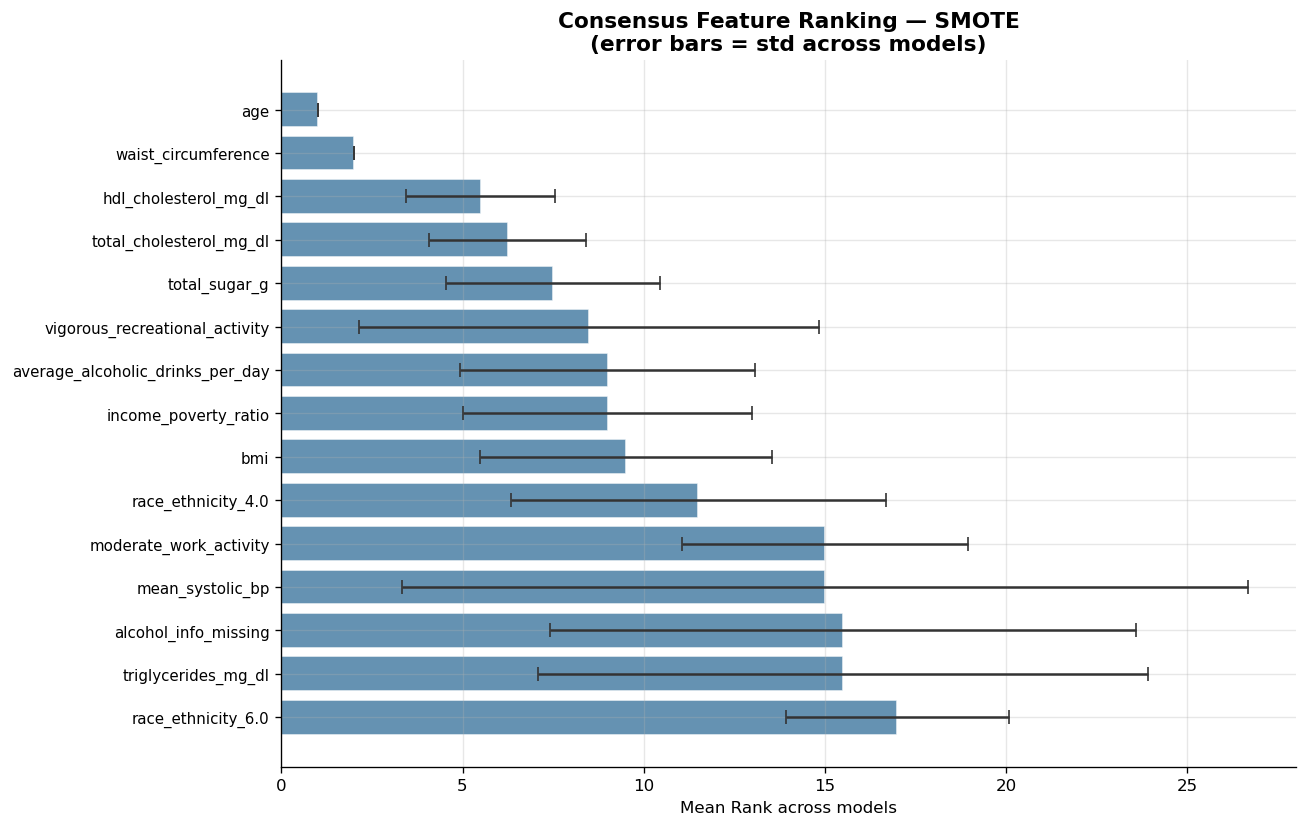

Top 15 consensus features (SMOTE):


Model,Decision Tree,Logistic Regression,Random Forest,XGBoost,Mean Rank,Rank Std
Feature,,,,,,
age,1.0,1.0,1.0,1.0,1.00,0.00
waist_circumference,2.0,2.0,2.0,2.0,2.00,0.00
hdl_cholesterol_mg_dl,7.0,3.0,4.0,8.0,5.50,2.06
total_cholesterol_mg_dl,3.0,9.0,6.0,7.0,6.25,2.17
total_sugar_g,8.0,4.0,12.0,6.0,7.50,2.96
vigorous_recreational_activity,4.0,8.0,3.0,19.0,8.50,6.34
average_alcoholic_drinks_per_day,11.0,14.0,8.0,3.0,9.00,4.06
income_poverty_ratio,5.0,5.0,13.0,13.0,9.00,4.00
bmi,13.0,6.0,5.0,14.0,9.50,4.03


In [8]:
# Pivot: rows = features, columns = models, values = rank
rank_pivot_smote = smote_df.pivot_table(
    index="Feature", columns="Model", values="Rank"
)

rank_pivot_smote["Mean Rank"] = rank_pivot_smote.mean(axis=1)
rank_pivot_smote["Rank Std"]  = rank_pivot_smote.std(axis=1)
rank_pivot_smote = rank_pivot_smote.sort_values("Mean Rank")

top15 = rank_pivot_smote.head(15)

fig, ax = plt.subplots(figsize=(11, 7))

y_pos = np.arange(len(top15))
ax.barh(y_pos, top15["Mean Rank"],
        xerr=top15["Rank Std"],
        color="#4a7fa5", edgecolor="white",
        alpha=0.85, error_kw={"elinewidth": 1.5, "capsize": 4, "ecolor": "#333"})

ax.set_yticks(y_pos)
ax.set_yticklabels(top15.index, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("Mean Rank across models", fontsize=10)
ax.set_title("Consensus Feature Ranking — SMOTE\n(error bars = std across models)",
             fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig("../results/figures/model_feature_consistency/model_a_consensus_ranking.png", bbox_inches="tight")
plt.show()

print("Top 15 consensus features (SMOTE):")
display(rank_pivot_smote.head(15).round(2))


---
# Section B — Undersampling

All four models trained with random undersampling are compared on their SHAP feature rankings.

## B1. Top-10 Feature Rankings per Model (Undersampling)

The top 10 features by mean absolute SHAP value for each model trained with undersampling.

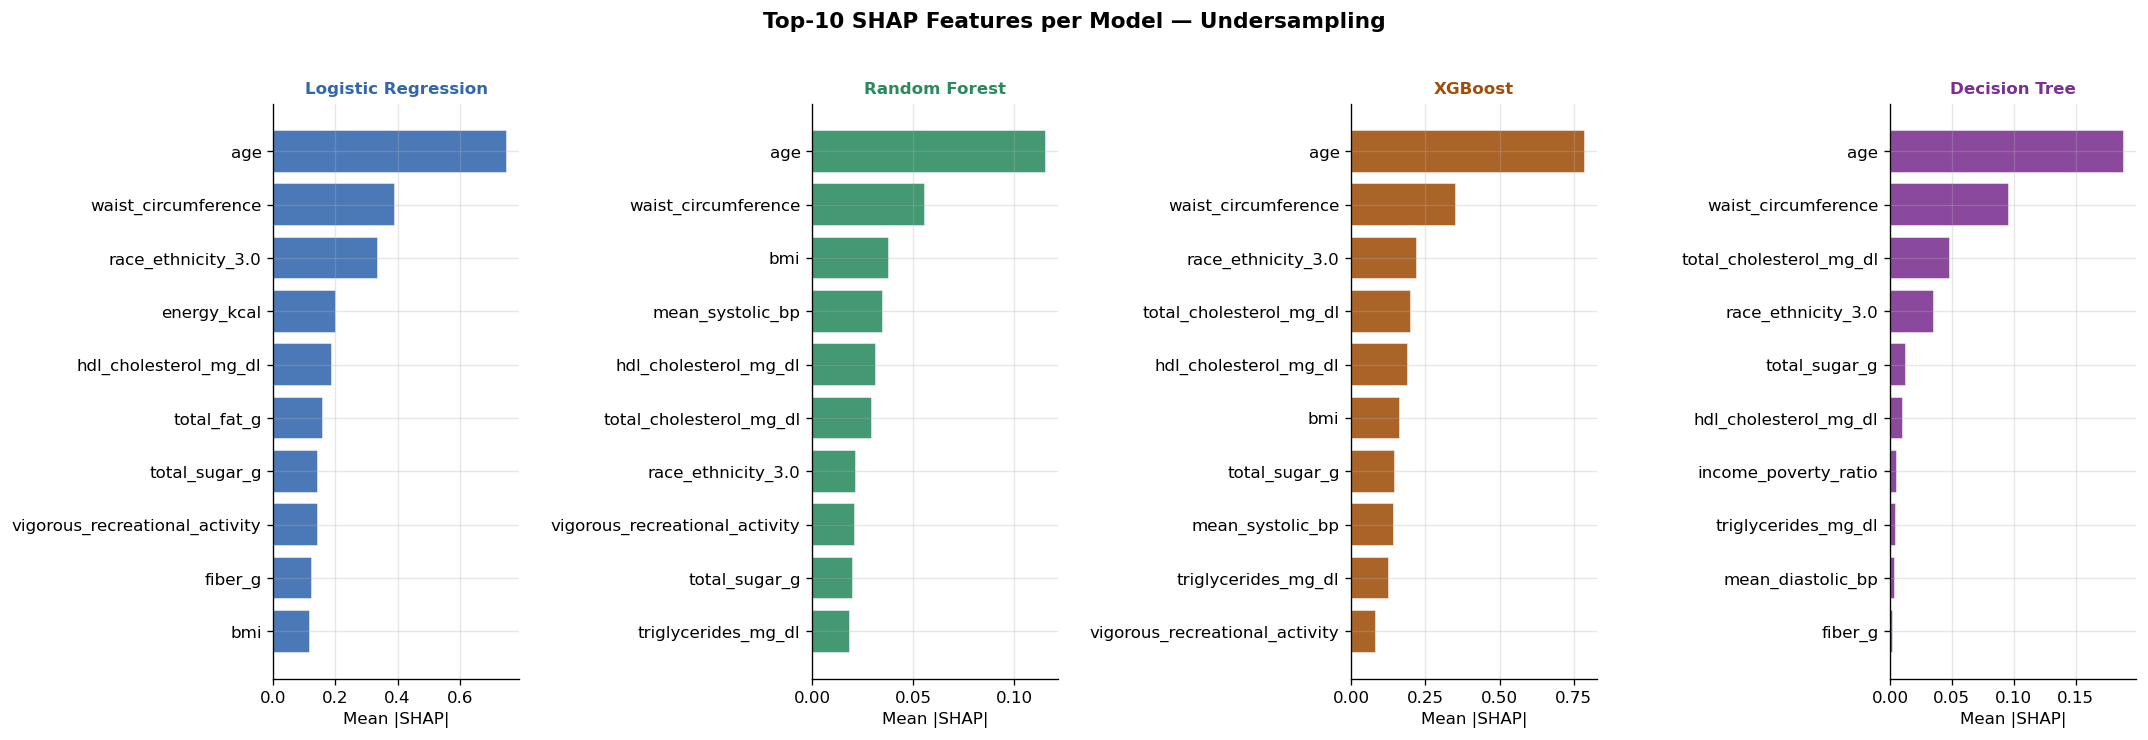

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(18, 6), sharey=False)

for ax, model in zip(axes, MODELS):
    subset = under_df[under_df["Model"] == model].nsmallest(TOP_N, "Rank")
    if subset.empty:
        ax.set_title(f"{model}\n(no data)", fontsize=10)
        continue
    subset = subset.sort_values("Importance", ascending=True)
    ax.barh(subset["Feature"], subset["Importance"],
            color=MODEL_COLORS[model], edgecolor="white", alpha=0.88)
    ax.set_title(model, fontsize=10, fontweight="bold", color=MODEL_COLORS[model])
    ax.set_xlabel("Mean |SHAP|")

fig.suptitle(f"Top-{TOP_N} SHAP Features per Model — Undersampling",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../results/figures/model_feature_consistency/model_b_top10_bars.png", bbox_inches="tight")
plt.show()


## B2. Top-10 Overlap Heatmap (Undersampling)

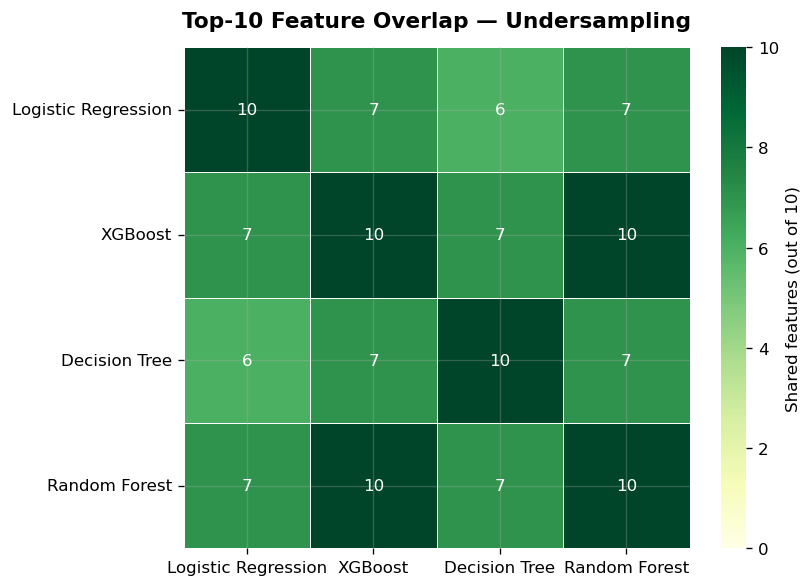

Mean pairwise overlap (excl. diagonal): 7.33


In [10]:
overlap_under = build_pairwise_matrix(shap_df, "Undersampling", top_n_overlap)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    overlap_under.astype(float),
    annot=True, fmt=".0f", cmap="YlGn",
    vmin=0, vmax=TOP_N,
    linewidths=0.5, linecolor="white",
    ax=ax, cbar_kws={"label": f"Shared features (out of {TOP_N})"}
)
ax.set_title(f"Top-{TOP_N} Feature Overlap — Undersampling",
             fontsize=13, fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig("../results/figures/model_feature_consistency/model_b_overlap_heatmap.png", bbox_inches="tight")
plt.show()

print("Mean pairwise overlap (excl. diagonal):",
      round(overlap_under.values[np.triu_indices_from(overlap_under.values, k=1)].mean(), 2))


## B3. Spearman Rank Correlation Heatmap (Undersampling)

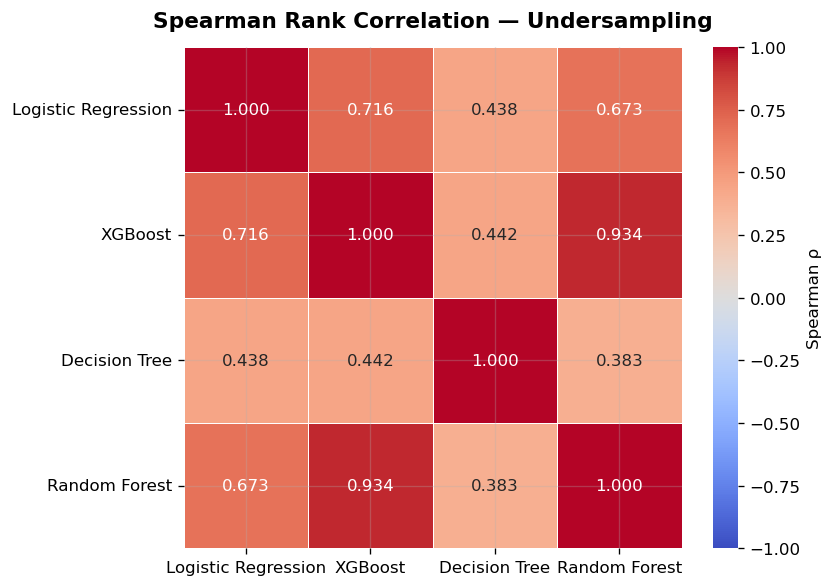

Mean Spearman ρ (excl. diagonal): 0.598
Min: 0.383  Max: 0.934


In [11]:
spearman_under = build_pairwise_matrix(shap_df, "Undersampling", spearman_correlation)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    spearman_under.astype(float),
    annot=True, fmt=".3f", cmap="coolwarm",
    vmin=-1, vmax=1, center=0,
    linewidths=0.5, linecolor="white",
    ax=ax, cbar_kws={"label": "Spearman ρ"}
)
ax.set_title("Spearman Rank Correlation — Undersampling",
             fontsize=13, fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig("../results/figures/model_feature_consistency/model_b_spearman_heatmap.png", bbox_inches="tight")
plt.show()

vals = spearman_under.values[np.triu_indices_from(spearman_under.values, k=1)]
print(f"Mean Spearman ρ (excl. diagonal): {vals.mean():.3f}")
print(f"Min: {vals.min():.3f}  Max: {vals.max():.3f}")


## B4. Jaccard Similarity (Undersampling)

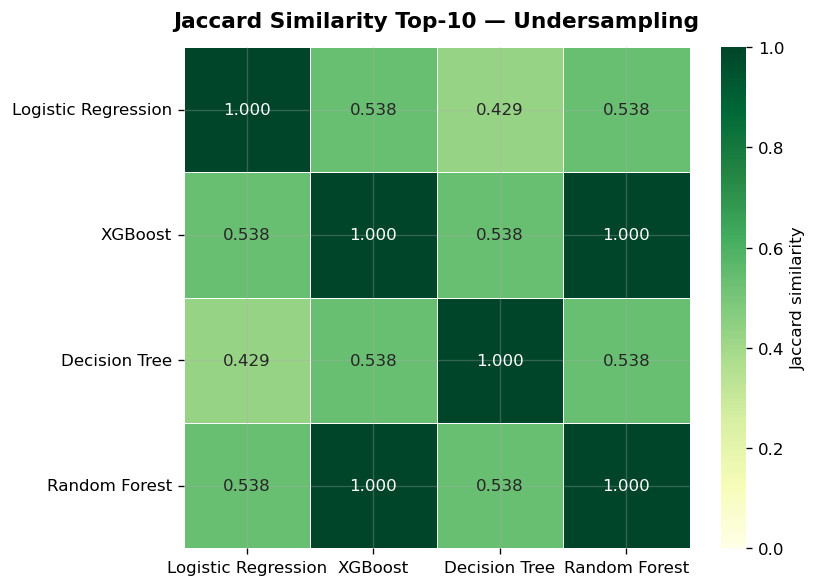

In [12]:
jaccard_under = build_pairwise_matrix(shap_df, "Undersampling", jaccard_similarity)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    jaccard_under.astype(float),
    annot=True, fmt=".3f", cmap="YlGn",
    vmin=0, vmax=1,
    linewidths=0.5, linecolor="white",
    ax=ax, cbar_kws={"label": "Jaccard similarity"}
)
ax.set_title(f"Jaccard Similarity Top-{TOP_N} — Undersampling",
             fontsize=13, fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig("../results/figures/model_feature_consistency/model_b_jaccard_heatmap.png", bbox_inches="tight")
plt.show()


## B5. Consensus Feature Ranking (Undersampling)

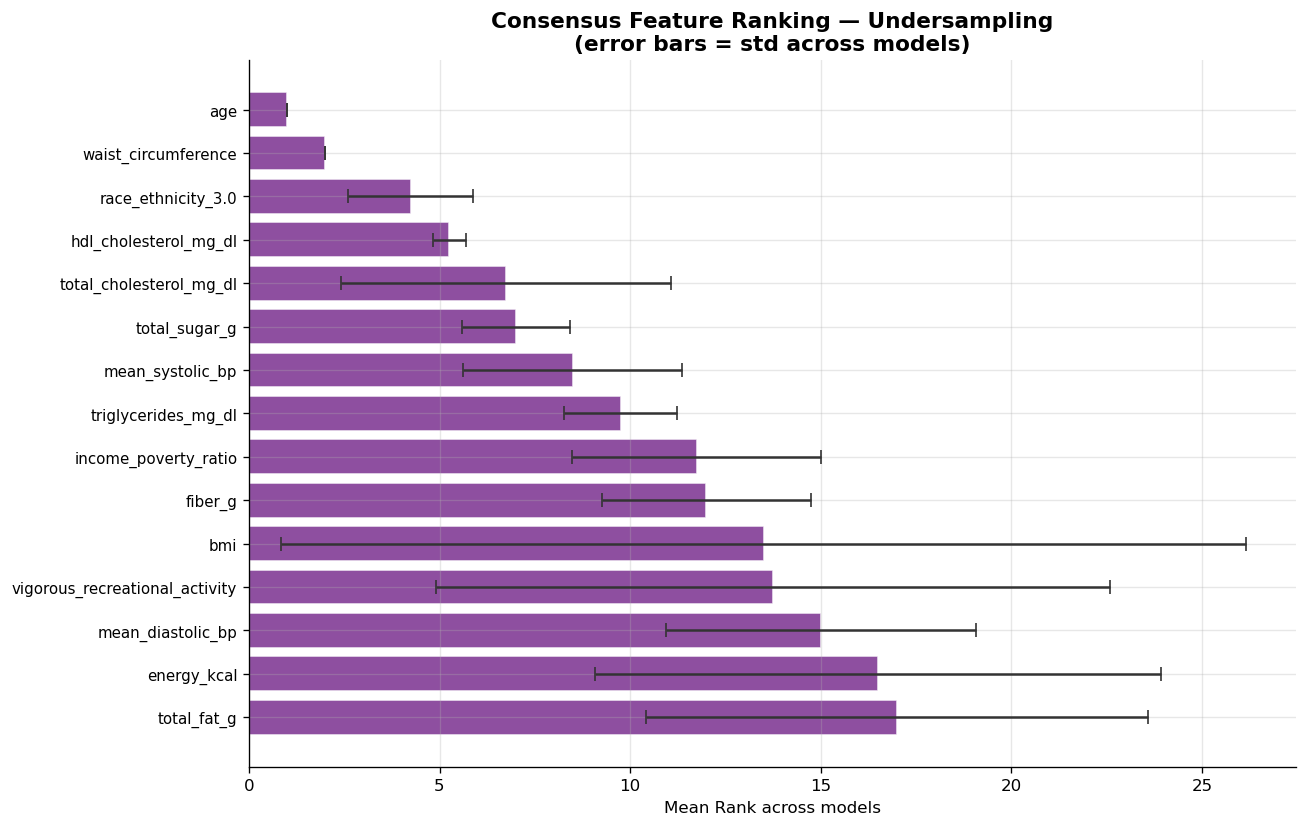

Top 15 consensus features (Undersampling):


Model,Decision Tree,Logistic Regression,Random Forest,XGBoost,Mean Rank,Rank Std
Feature,,,,,,
age,1.0,1.0,1.0,1.0,1.00,0.00
waist_circumference,2.0,2.0,2.0,2.0,2.00,0.00
race_ethnicity_3.0,4.0,3.0,7.0,3.0,4.25,1.64
hdl_cholesterol_mg_dl,6.0,5.0,5.0,5.0,5.25,0.43
total_cholesterol_mg_dl,3.0,14.0,6.0,4.0,6.75,4.32
total_sugar_g,5.0,7.0,9.0,7.0,7.00,1.41
mean_systolic_bp,11.0,11.0,4.0,8.0,8.50,2.87
triglycerides_mg_dl,8.0,12.0,10.0,9.0,9.75,1.48
income_poverty_ratio,7.0,16.0,13.0,11.0,11.75,3.27


In [13]:
rank_pivot_under = under_df.pivot_table(
    index="Feature", columns="Model", values="Rank"
)

rank_pivot_under["Mean Rank"] = rank_pivot_under.mean(axis=1)
rank_pivot_under["Rank Std"]  = rank_pivot_under.std(axis=1)
rank_pivot_under = rank_pivot_under.sort_values("Mean Rank")

top15 = rank_pivot_under.head(15)

fig, ax = plt.subplots(figsize=(11, 7))

y_pos = np.arange(len(top15))
ax.barh(y_pos, top15["Mean Rank"],
        xerr=top15["Rank Std"],
        color="#7a3090", edgecolor="white",
        alpha=0.85, error_kw={"elinewidth": 1.5, "capsize": 4, "ecolor": "#333"})

ax.set_yticks(y_pos)
ax.set_yticklabels(top15.index, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("Mean Rank across models", fontsize=10)
ax.set_title("Consensus Feature Ranking — Undersampling\n(error bars = std across models)",
             fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig("../results/figures/model_feature_consistency/model_b_consensus_ranking.png", bbox_inches="tight")
plt.show()

print("Top 15 consensus features (Undersampling):")
display(rank_pivot_under.head(15).round(2))
